### Find widths and see how it looks

In [1]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors

from cluster import *


# get working directory
os.chdir("d:\\MasterThesis")
os.getcwd()

'd:\\MasterThesis'

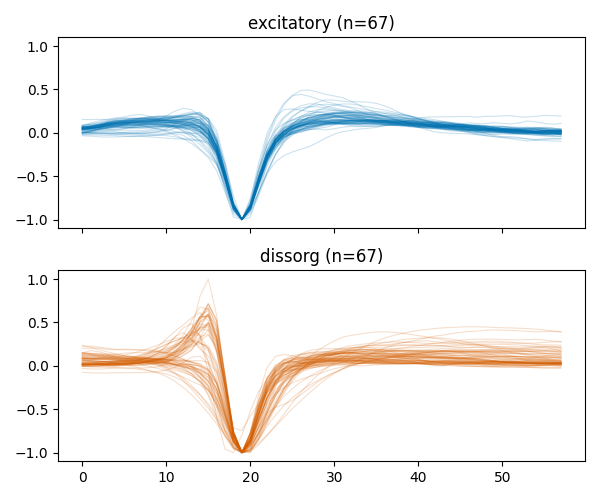

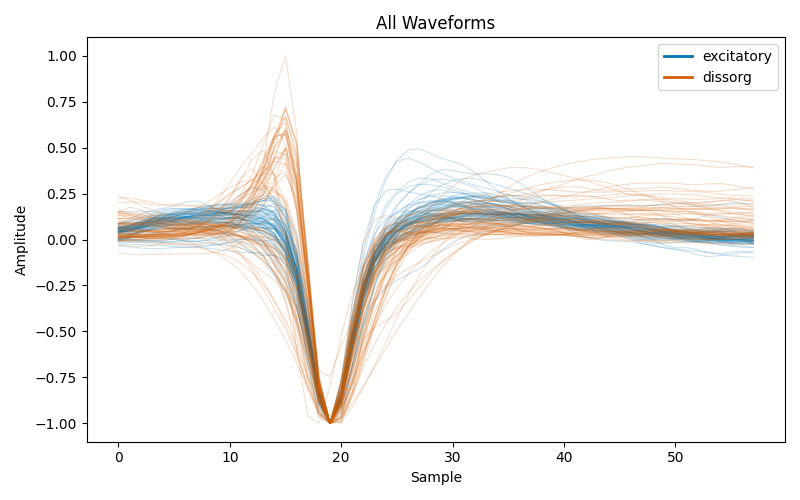

In [2]:
data_path_dissorg = "d:\\MasterThesis\\processed_data\\NEW_BRW_average_waveforms_filtered_dissorg_noflip25.csv"
data_path_excit = "d:\\MasterThesis\\processed_data\\NEW_BRW_average_waveforms_filtered_excit_noflip25.csv"

data_list = [data_path_excit, data_path_dissorg] 
data_labels = ['excitatory', 'dissorg']   

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels, plot=True)

In [17]:
# function to calculate the widths of each waveform at a given height

def get_widths(wf_array, amp=-0.5):
    """
    Width at amplitude amp, using the two crossings that flank the waveform minimum.

    Parameters
    ----------
    wf_array : (n_waveforms, n_samples) ndarray
    amp : float
        Threshold amplitude.

    Returns
    -------
    widths : ndarray
        Widths in samples.
    """
    widths = np.full(len(wf_array), np.nan)

    for i, wf in enumerate(wf_array):

        min_idx = np.argmin(wf)

        # Left crossing
        left_candidates = np.where((wf[:min_idx] > amp) & (wf[1:min_idx+1] <= amp))[0]

        if len(left_candidates) == 0:
            continue

        j_left = left_candidates[-1]

        x_left = j_left + ((amp - wf[j_left]) /(wf[j_left + 1] - wf[j_left]))

        # Right crossing
        right_candidates = np.where((wf[min_idx:-1] <= amp) &(wf[min_idx+1:] > amp))[0]

        if len(right_candidates) == 0:
            continue

        j_right = right_candidates[0] + min_idx

        x_right = j_right + ((amp - wf[j_right]) /(wf[j_right + 1] - wf[j_right]))

        widths[i] = x_right - x_left

    return widths


def plot_width_histogram(widths, title = "test", bins=30):

    widths = np.asarray(widths)

    # Remove failed measurements
    widths = widths[~np.isnan(widths)]

    plt.figure(figsize=(6, 4))
    plt.hist(widths, bins=bins)
    median_width = np.nanmedian(widths)
    plt.axvline(median_width, linestyle="--",label=f"Median = {median_width:.2f}")
    plt.legend()
    plt.xlabel("Width (samples)")
    plt.ylabel("Count")
    plt.title(f"Waveform Width Distribution - {title}")
    plt.tight_layout()
    plt.show()

In [ ]:
test_widths = get_widths(all_wf, amp=-0.5)

In [6]:
print(all_wf.shape)
print(test_widths.shape)

(134, 58)
(134,)


---

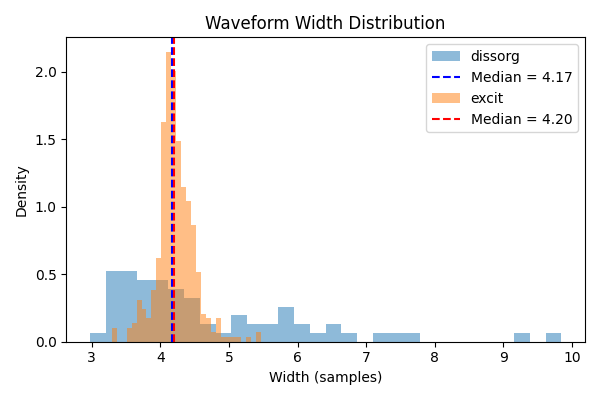

In [26]:
# Load the data
wf_dissorg, labels_base = load_and_stack_waveforms(pathlist=[data_path_dissorg], labellist=['dissorg'], plot=False)
wf_excit, labels_excit = load_and_stack_waveforms(pathlist=[data_path_excit], labellist=['excitatory'], plot=False)

widths_dissorg_half = get_widths(wf_dissorg, amp=-0.5)
widths_excit_half = get_widths(wf_excit, amp=-0.5)


plt.figure(figsize=(6, 4))
bins = 30
plt.hist(widths_dissorg_half, bins=bins, label="dissorg", alpha = 0.5, density=True)
median_width_dissorg = np.nanmedian(widths_dissorg_half)
plt.axvline(median_width_dissorg, linestyle="--", c="b", label=f"Median = {median_width_dissorg:.2f}")

plt.hist(widths_excit_half, bins=bins, label="excit", alpha = 0.5, density=True)
median_width_excit = np.nanmedian(widths_excit_half)
plt.axvline(median_width_excit, linestyle="--", c="r", label=f"Median = {median_width_excit:.2f}")

plt.legend()
plt.xlabel("Width (samples)")
plt.ylabel("Density")
plt.title(f"Waveform Width Distribution")
plt.tight_layout()
plt.show()


### gabazine

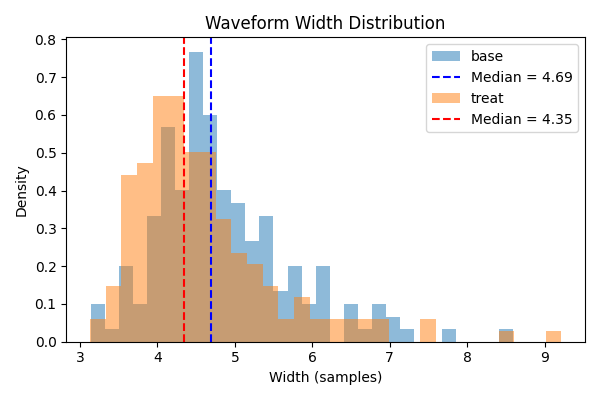

In [27]:
data_path_base = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_gbz_baseline.csv"
data_path_treat = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_gbz_treat.csv"

wf_base, labels_base = load_and_stack_waveforms(pathlist=[data_path_base], labellist=['base'], plot=False)
wf_treat, labels_treat = load_and_stack_waveforms(pathlist=[data_path_treat], labellist=['treat'], plot=False)

widths_base_half = get_widths(wf_base, amp=-0.5)
widths_treat_half = get_widths(wf_treat, amp=-0.5)


plt.figure(figsize=(6, 4))
bins = 30
plt.hist(widths_base_half, bins=bins, label="base", alpha = 0.5, density=True)
median_width_base = np.nanmedian(widths_base_half)
plt.axvline(median_width_base, linestyle="--", c="b", label=f"Median = {median_width_base:.2f}")

plt.hist(widths_treat_half, bins=bins, label="treat", alpha = 0.5, density=True)
median_width_treat = np.nanmedian(widths_treat_half)
plt.axvline(median_width_treat, linestyle="--", c="r", label=f"Median = {median_width_treat:.2f}")

plt.legend()
plt.xlabel("Width (samples)")
plt.ylabel("Density")
plt.title(f"Waveform Width Distribution")
plt.tight_layout()
plt.show()
